In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import os

import matplotlib.pyplot as plt
from eyewire2_functional_analysis import data_loader

In [25]:
data_root = "../../../data"
data_folder = f"{data_root}/preprocessed-data"
morph_folder = f"{data_root}/morphological-data"
print(sorted(os.listdir(morph_folder)))

['Eyewire II Proofread Cells Main List - All Cells 2026-05-09b-resource-paper-v2.csv', 'Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv', 'roi_mapping_2p_to_em.csv']


In [26]:
df_rois, df_fields, df_outline = data_loader.load_all_dfs(data_folder)

df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Main List - All Cells 2026-05-09b-resource-paper-v2.csv',
    nuc_col_master='Latest NucID',
    seg_col_master=(
        'Latest SegID',
        'Proofread SegID'),
    df_rois=df_rois,
)

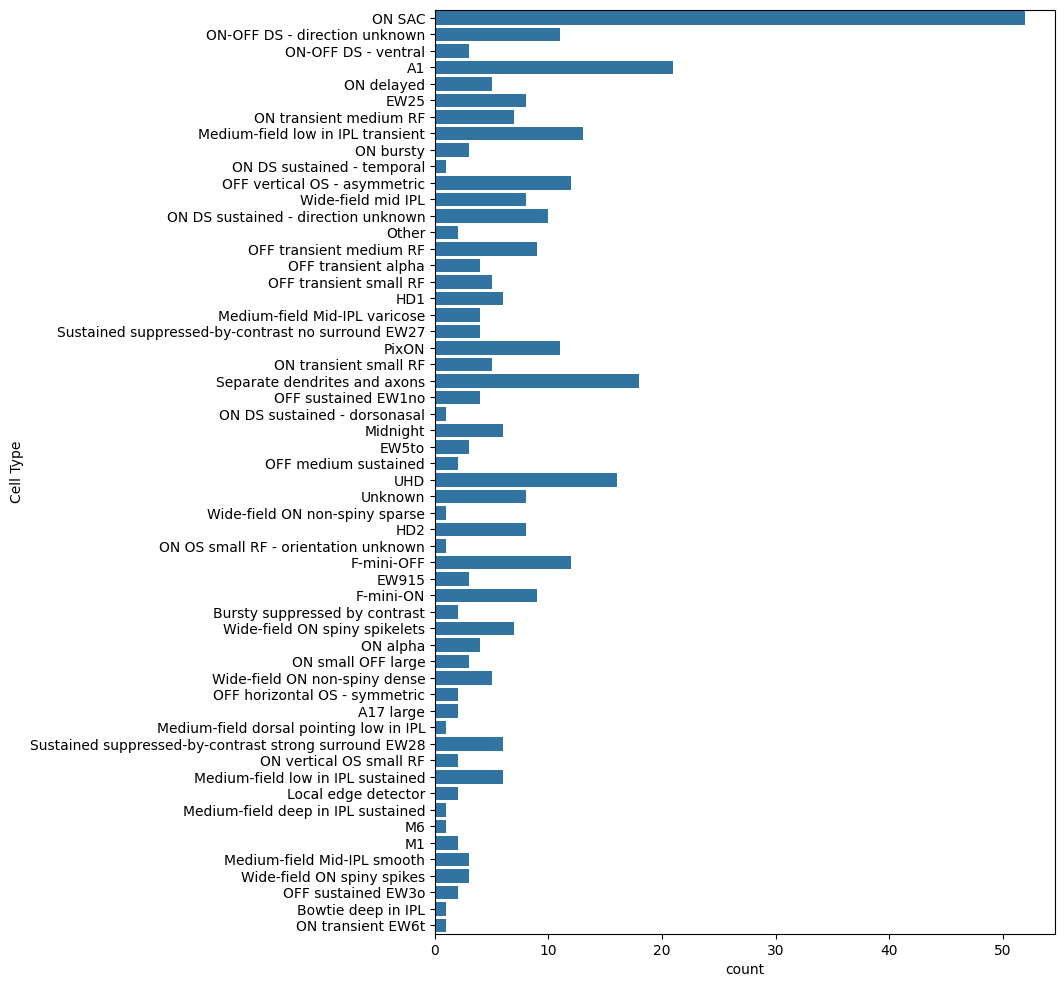

In [27]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df, y='Cell Type')
plt.show()

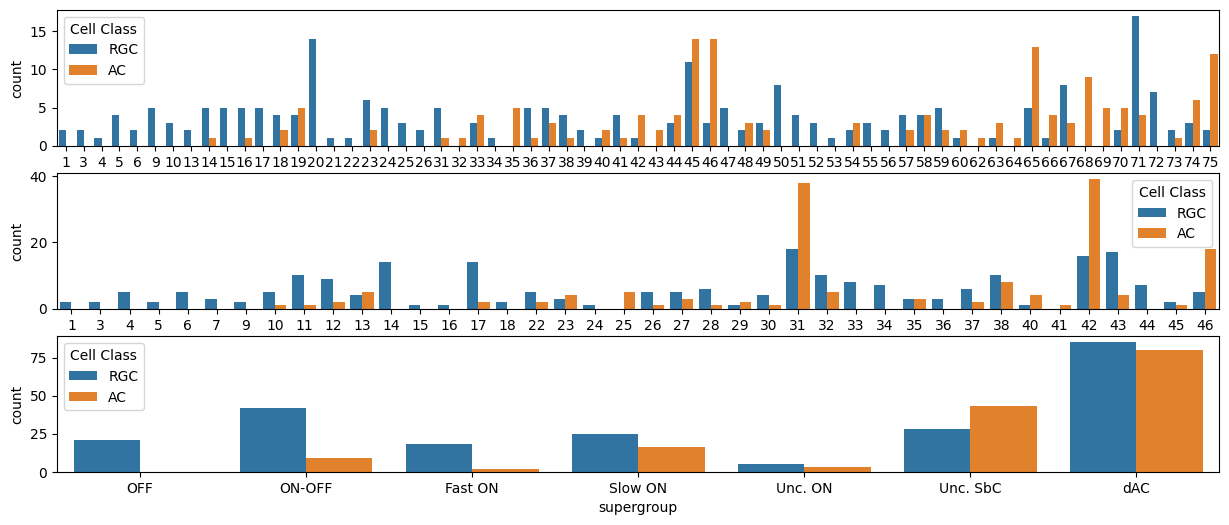

In [29]:
fig, ax = plt.subplots(3, 1, figsize=(15, 6))
sns.countplot(ax=ax[0], data=df, x='cluster_id', hue='Cell Class', hue_order=['RGC', 'AC'])
sns.countplot(ax=ax[1], data=df, x='group_id', hue='Cell Class', hue_order=['RGC', 'AC'])
sns.countplot(ax=ax[2], data=df, x='supergroup', hue='Cell Class', hue_order=['RGC', 'AC'],
              order=['OFF', 'ON-OFF', 'Fast ON', 'Slow ON', 'Unc. ON', 'Unc. SbC', 'dAC'])
plt.show()